# Tech Challenge - Previsão de Custos Médicos 🏥📊

## Objetivo
Desenvolver um modelo preditivo capaz de estimar o custo médico individual com base em características pessoais.

## Bibliotecas utilizadas

In [156]:
# Bibliotecas importadas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sci
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


## Datasets utilizados

In [157]:
# Link do dataset:
# https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset/data

# Carregar o dataset
df = pd.read_csv('Dataset/insurance.csv')

# Análise Exploratória dos Dados

In [158]:
# Visualizar as primeiras linhas do dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [159]:
# Visualizar o shape do dataset
df.shape

(1338, 7)

In [160]:
# Visualizar as informações gerais sobre cada coluna e verificar se o data type atribuído a cada coluna faz sentido
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [161]:
# Verificar se a coluna 'sex' possue valores numéricos
set(df['sex'])

{'female', 'male'}

In [162]:
# Verificar se a coluna 'smoker' possue valores numéricos
set(df['smoker'])

{'no', 'yes'}

In [163]:
# Verificar se a coluna 'region' possue valores numéricos
set(df['region'])

{'northeast', 'northwest', 'southeast', 'southwest'}

Os data types das colunas estão corretos e nas colunas do tipo 'object' não há valores numéricos.

In [164]:
# Visualizar as estatísticas descritivas das colunas numéricas
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


As escalas dos dados entre as colunas estão muito diferentes, será necessário aplicar a padronização desses dados.

O range de idade vai de 18 a 64 anos, isso significa por exemplo que esse hospital não trata de crianças e adolescentes ou pessoas acima de 64 anos? seria importante confirmar com a área de negócio se esse range esta correto ou se estão faltando dados de determinadas faixas etárias pois se for esse o caso então o modelo não conseguirá realizar a predição de custo corretamente para esses cenários (pacientes abaixo de 18 ou acima de 64 anos).

In [165]:
# Verificar se há valores nulos
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Distribuição dos Dados

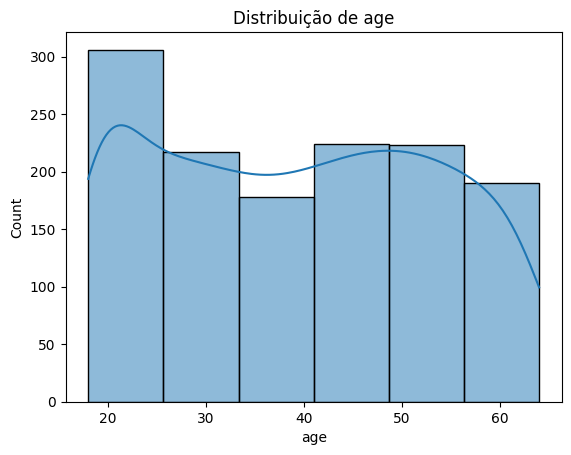

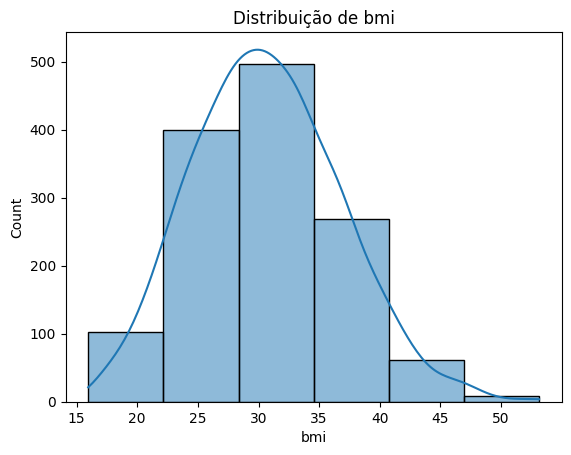

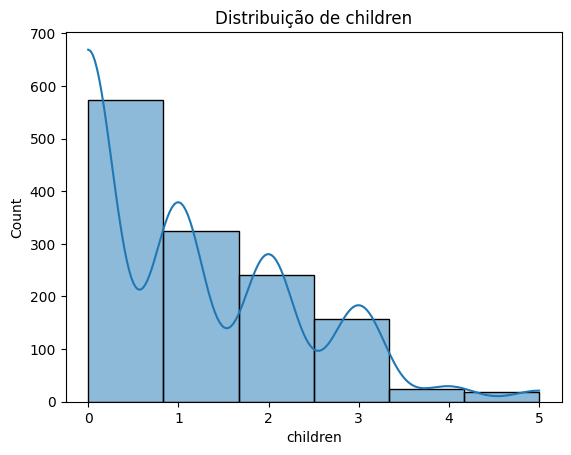

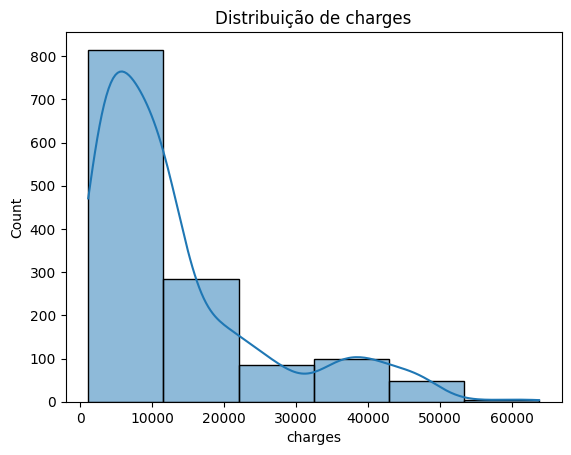

In [166]:
# Visualizar as distribuições das colunas numéricas
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=6)
    plt.title(f'Distribuição de {col}')
    plt.show()

In [167]:
# Verificar se os dados seguem a Curva Gaussiana
# Teste de Shapiro-Wilk
for column in df[num_cols]:
  stat, p_value = sci.shapiro(df[column])
  print(f'Coluna: {column}, Estatística de teste: {round(stat, 3)}, Valor de p: {p_value}')

  if p_value > 0.05:
        print(f'Essa coluna parece seguir uma distribuição normal.\n')
  else:
        print(f'Essa coluna não parece seguir uma distribuição normal.\n')

Coluna: age, Estatística de teste: 0.945, Valor de p: 5.69204692845418e-22
Essa coluna não parece seguir uma distribuição normal.

Coluna: bmi, Estatística de teste: 0.994, Valor de p: 2.60468368798344e-05
Essa coluna não parece seguir uma distribuição normal.

Coluna: children, Estatística de teste: 0.823, Valor de p: 5.066436570900864e-36
Essa coluna não parece seguir uma distribuição normal.

Coluna: charges, Estatística de teste: 0.815, Valor de p: 1.1505226334932036e-36
Essa coluna não parece seguir uma distribuição normal.



Concluímos que os dados de nenhuma das colunas segue uma curva gaussiana, ou seja, esses dados não estão com uma distribuição normalizada. Embora isso não seja um impeditivo para utilização de modelos de regressão linear é importante ressaltar que modelos de regressão linear funcionam melhor com dados gaussianos.

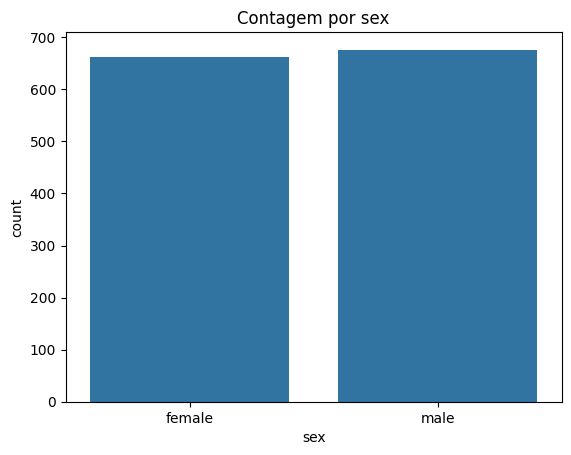

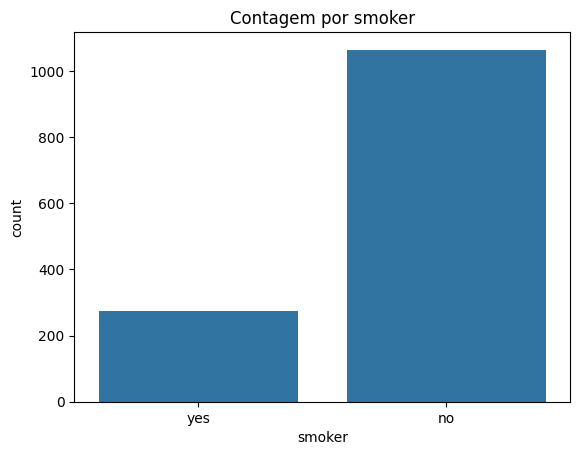

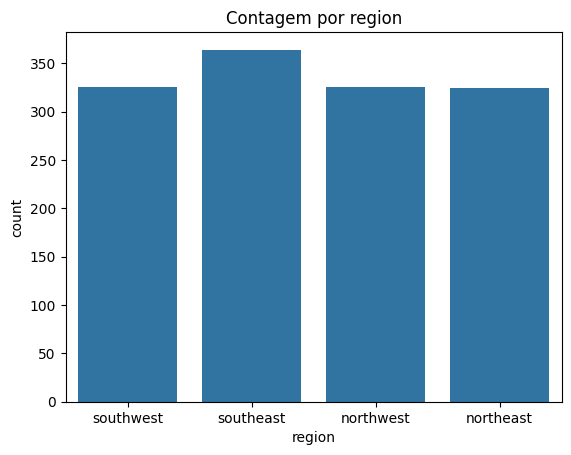

In [168]:
#  Visualizar as distribuições das colunas categóricas
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f'Contagem por {col}')
    plt.show()

A distribuição dos dados pelas colunas 'sex' e 'region' estão balanceadas enquanto que na coluna 'smoker' os dados estão desbalanceados. Isso pode fazer com que o algoritmo ML faça a predição dos custos médicos melhor para os pacientes que não fumam do que para os pacientes que fumam devido a diferença no número de amostras entre as opções dessa coluna.

## Relacionamento entre as variáveis descritivas com a variável target

### Os custos médicos aumentam de acordo com a idade dos pacientes?

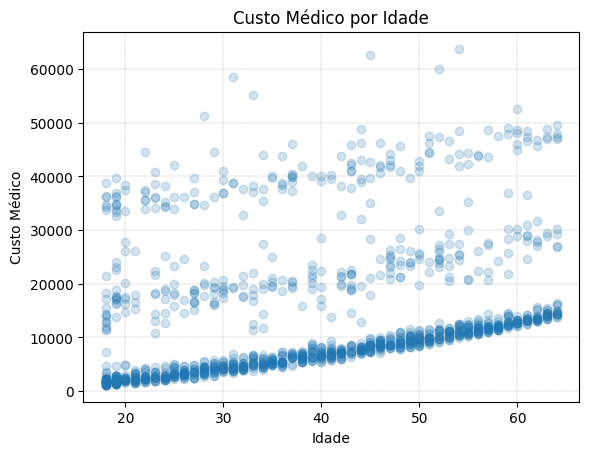

In [169]:
# Verificar a relação entre a idade do paciente e os custos médicos
plt.scatter(df['age'], df['charges'], alpha=0.2)
plt.grid(color='gray', linestyle='--', linewidth=0.2)
plt.xlabel('Idade')
plt.ylabel('Custo Médico')
plt.title('Custo Médico por Idade')
plt.show()

É uma tendência **(não é uma regra!)** que pessoas de mais idade tenham custos médicos maiores do que pessoas com menos idade e nesse gráfico vemos que essa relação (aumento de gastos médicos devido a idade) esta ocorrendo porém de forma sutil. Vemos 3 séries de dados onde os gastos médicos vão aumentando conforme a idade da paciente aumenta.

### Os custos médicos aumentam de acordo com o BMI (Índice de Massa Corporal) dos pacientes?

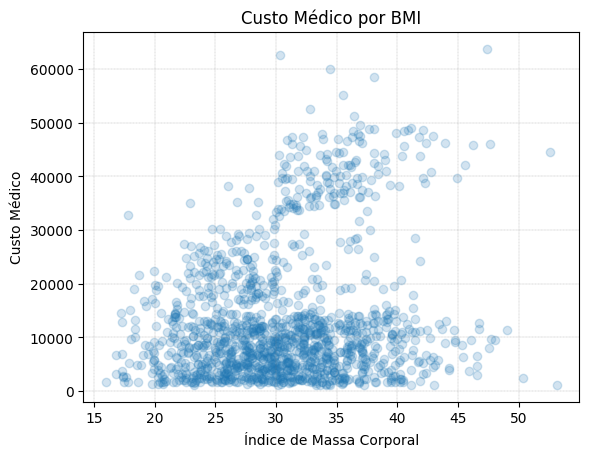

In [170]:
# Verificar a relação entre o bmi do paciente e os custos médicos
plt.scatter(df['bmi'], df['charges'], alpha=0.2)
plt.grid(color='gray', linestyle='--', linewidth=0.2)
plt.xlabel('Índice de Massa Corporal')
plt.ylabel('Custo Médico')
plt.title('Custo Médico por BMI')
plt.show()

Podemos perceber que os pacientes com o BMI menor do que 30 possuem menos gastos médicos do que os pacientes com BMI acima de 30 (BMI acima de 30 é considerado obesidade).

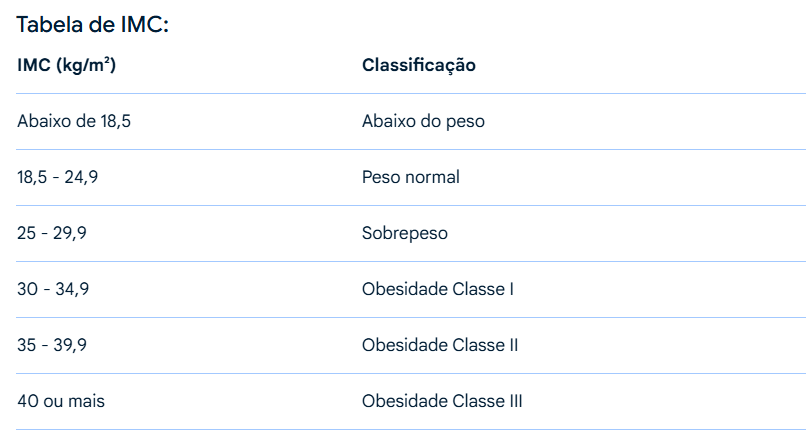

### Existe alguma relação entre os custos médicos e o fato do paciente ser fumante ou não?

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 37.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 60.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


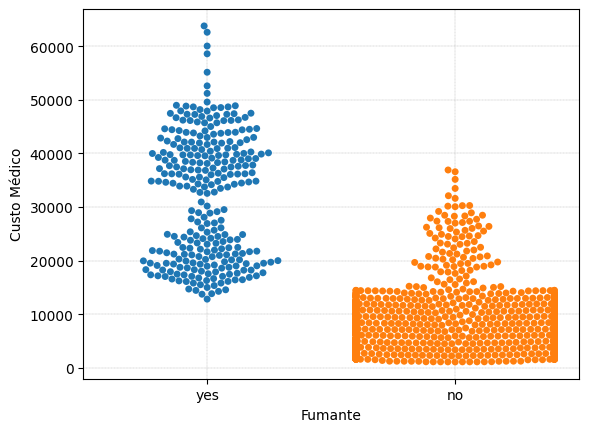

In [171]:
# Verificar a relação entre os custos médicos e se o paciente é ou não fumante
sns.swarmplot(df, x='smoker', y='charges', hue='smoker')
plt.grid(color='gray', linestyle='--', linewidth=0.2)
plt.xlabel('Fumante')
plt.ylabel('Custo Médico')
plt.show()

Vemos que o fato do paciente ser ou não fumante impacta diretamente nos seus custos médicos, pacientes que fumam gastam muito mais do que os pacientes que não fumam.

### Checando a variabilidade e possíveis outiliers em nosso dataset

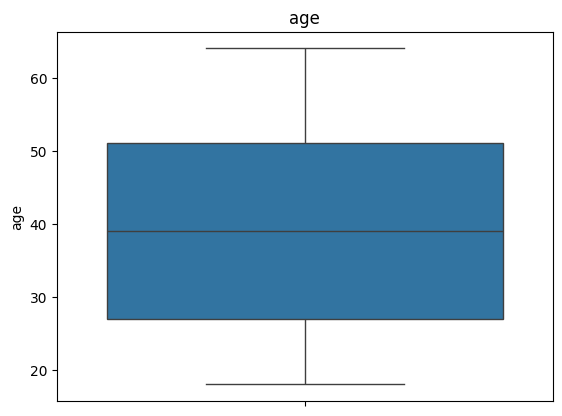

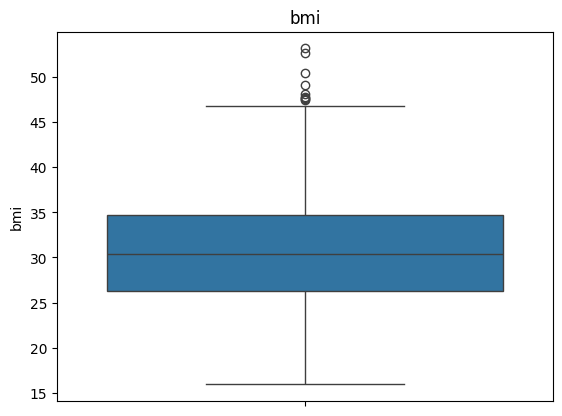

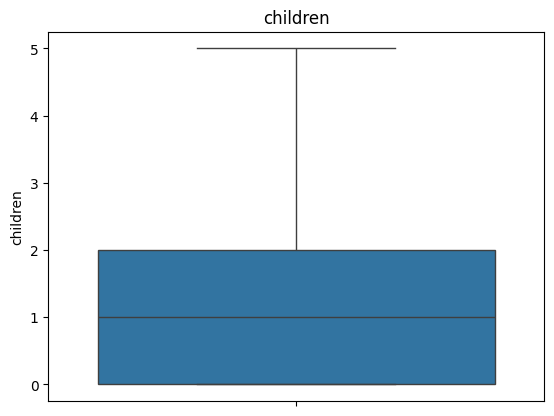

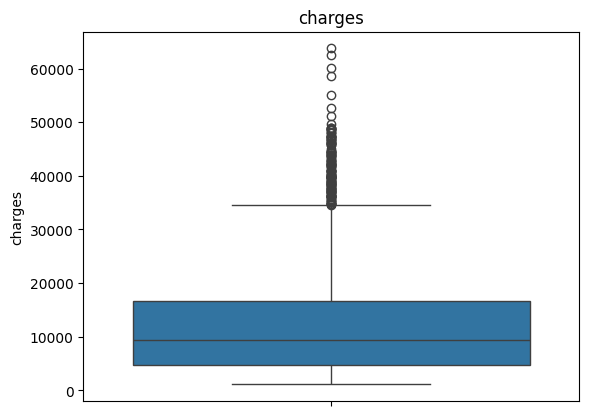

In [172]:
# Visualizar a variância e possiveis outliers nas colunas numéricas
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

Foram detectados alguns outliers nas colunas 'bmi' e 'charges' porém é preciso checar com a área de negócio se eles são realmente outliers uma vez que é possivel uma pessoa possuir um índice de massa corporal maior que 45 e no caso dos custos médicos os custos mais elevados podem ter sido devido a internações ou tratamentos prolongados (como tratamento contra câncer).

### Correlação entre as variáveis

Primeiro vamos transformar as variáveis categóricas em numéricas para podermos adiciona-las em nossa matriz de correlação (essa matriz só aceita colunas do tipo numérico).

In [173]:
# Transformar as variáveis categóricas em variáveis númericas
label_encoder_colunms = ['sex', 'smoker']

# Criar uma cópia do dataset
df_label = df.copy()

# Aplicar o label encoder
label_encoder = LabelEncoder()

for col in label_encoder_colunms:
    df_label[col] = label_encoder.fit_transform(df_label[col])

# Aplicar o one-hot enconder
df_label = pd.get_dummies(df_label, columns=['region'], dtype=np.int8)

In [174]:
# Mostrar as primeiras linhas do novo dataset gerado
df_label.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


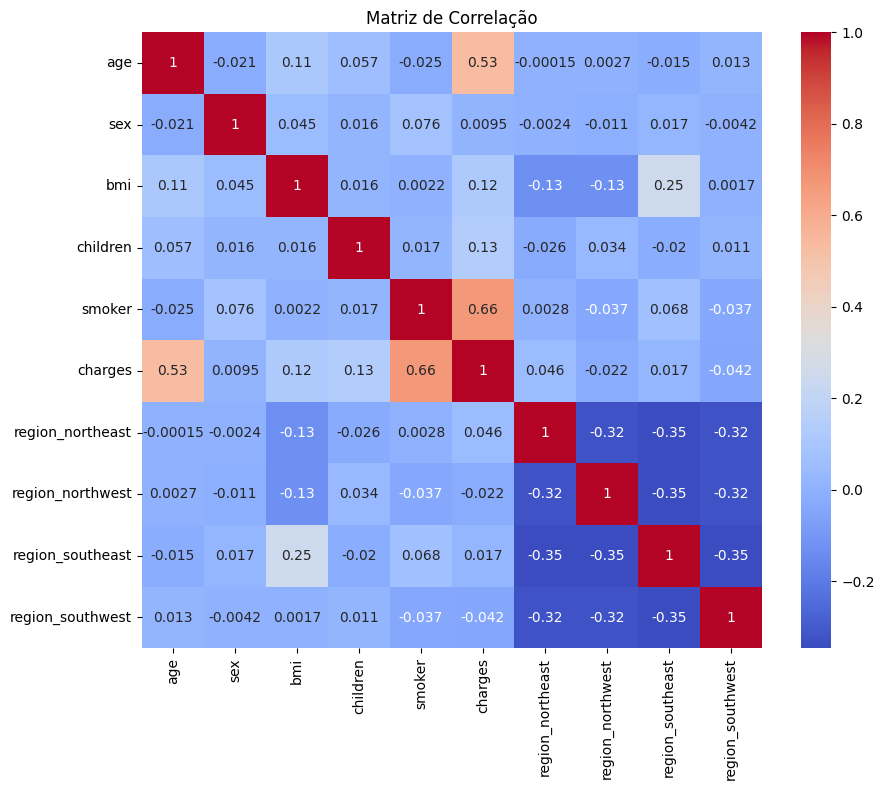

In [175]:
# Matriz de Correlação
plt.figure(figsize=(10,8))
sns.heatmap(df_label.select_dtypes(include=np.number).corr(method='spearman'), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

Exceto pelas colunas 'age' e 'smoker' que possuem uma correlação relativamente alta com a coluna target, a correlação entre as variáveis em geral é baixa. Isso é um ponto de atenção pois modelos de regressão linear são mais precisos em suas previsões quando há forte correlação entre as variáveis independentes e a variável dependente (target).


# Realizar o pré-processamento dos dados

Vamos separar do dataset original as variáveis features da variável target.

In [176]:
# Separar variáveis features e target
X = df.drop('charges', axis=1)
y = df['charges']

## Criar as bases de treino e teste

In [177]:
# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [178]:
# Visualizar o shape das bases de treino e teste
print(f'Dataset X:\nTreino: {X_train.shape}\nTeste: {X_test.shape}\n')

print(f'Dataset y:\nTreino: {y_train.shape}\nTeste: {y_test.shape}')

Dataset X:
Treino: (1070, 6)
Teste: (268, 6)

Dataset y:
Treino: (1070,)
Teste: (268,)


## Criar um pipeline de pré-processamento dos dados

Vamos criar um pipeline que execute os steps de transformação dos dados que são necessários em nosso dataset

In [179]:
# Definir a lista de colunas que serão usadas em cada step do pipeline
ordinal_encoder_colunms = ['sex', 'smoker']
onehot_encoder_colunms = ['region']
std_scaler_columns = ['age', 'bmi', 'children']

**Observação:** O ordinal encoding foi usado porque o label encoding não funciona em pipeline, no entanto, como as colunas possuem apenas 2 valores possiveis não há diferença entre ordinal e label encoding para esses casos.

In [180]:
# Criar o pipeline com as 3 transformações que serão aplicadas no dataset
full_pipeline = ColumnTransformer([
        ('ordinal_encoder', OrdinalEncoder(dtype=np.int8), ordinal_encoder_colunms), # aplicando ordinal encoder
        ('std_scaler', StandardScaler(), std_scaler_columns), # padronizando as escalas dos dados
        ('one_hot_encoder', OneHotEncoder(dtype=np.int8, sparse_output=False), onehot_encoder_colunms) # aplicando one-hot encoder
    ])

# Executar o Pipeline
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

Vamos criar um df com as 10 primeiras linhas do dataframe original, depois transformar essas linhas com o pipeline para posteriormente fazer uma comparação entre o dataframe editado e o dataframe original.

In [181]:
df_comparar = full_pipeline.transform(df.head(10).copy().drop('charges', axis=1))

O resultado final do pipeline é um array, e portanto, precisamos transforma-lo novamente em um dataframe.

In [182]:
# Lista das variáveis features
column_names = ['sex', 'smoker', 'age', 'bmi', 'children', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

# Transformar o array em DataFrame novamente
X_train_prepared = pd.DataFrame(data=X_train_prepared, columns=column_names)
X_test_prepared = pd.DataFrame(data=X_test_prepared, columns=column_names)
df_comparar = pd.DataFrame(data=df_comparar, columns=column_names)

In [183]:
# Visualizar as primeiras linhas do dataset transformado
df_comparar.head(10)

,sex,smoker,age,bmi,children,region_northeast,region_northwest,region_southeast,region_southwest
0,0.0,1.0,-1.447107,-0.440422,-0.911192,0.0,0.0,0.0,1.0
1,1.0,0.0,-1.518194,0.531342,-0.088428,0.0,0.0,1.0,0.0
2,1.0,0.0,-0.807329,0.403870,1.557100,0.0,0.0,1.0,0.0
3,1.0,0.0,-0.451897,-1.300442,-0.911192,0.0,1.0,0.0,0.0
4,1.0,0.0,-0.522984,-0.278186,-0.911192,0.0,1.0,0.0,0.0
5,0.0,0.0,-0.594070,-0.798005,-0.911192,0.0,0.0,1.0,0.0
6,0.0,0.0,0.472227,0.476711,-0.088428,0.0,0.0,1.0,0.0
7,0.0,0.0,-0.167551,-0.466910,1.557100,0.0,1.0,0.0,0.0
8,1.0,0.0,-0.167551,-0.120915,0.734336,1.0,0.0,0.0,0.0
9,0.0,0.0,1.467437,-0.781450,-0.911192,0.0,1.0,0.0,0.0


In [184]:
# Visualizar as primeiras linhas do dataset original
df[['sex', 'smoker', 'age', 'bmi', 'children', 'region']].head(10)

,sex,smoker,age,bmi,children,region
0,female,yes,19,27.900,0,southwest
1,male,no,18,33.770,1,southeast
2,male,no,28,33.000,3,southeast
3,male,no,33,22.705,0,northwest
4,male,no,32,28.880,0,northwest
5,female,no,31,25.740,0,southeast
6,female,no,46,33.440,1,southeast
7,female,no,37,27.740,3,northwest
8,male,no,37,29.830,2,northeast
9,female,no,60,25.840,0,northwest


Comparando as 10 primeiras linhas do dataset original com o dataset editado vemos que os dados estão batendo.

In [185]:
# Visualizar as estatísticas descritivas das colunas numéricas
X_train_prepared.describe()

,sex,smoker,age,bmi,children,region_northeast,region_northwest,region_southeast,region_southwest
count,1070.000000,1070.000000,1.070000e+03,1.070000e+03,1.070000e+03,1070.000000,1070.000000,1070.000000,1070.000000
mean,0.512150,0.205607,-1.992176e-16,-4.648410e-17,-2.324205e-17,0.249533,0.239252,0.264486,0.246729
std,0.500086,0.404334,1.000468e+00,1.000468e+00,1.000468e+00,0.432945,0.426827,0.441265,0.431309
min,0.000000,0.000000,-1.518194e+00,-2.417060e+00,-9.111921e-01,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,-8.784157e-01,-7.210253e-01,-9.111921e-01,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.016470e-02,-5.800739e-02,-8.842793e-02,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,8.276587e-01,6.515707e-01,7.343363e-01,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.751782e+00,3.736342e+00,3.202629e+00,1.000000,1.000000,1.000000,1.000000


In [186]:
# Visualizar as informações gerais sobre cada coluna e verificar se o data type atribuído a cada coluna faz sentido
X_train_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex               1070 non-null   float64
 1   smoker            1070 non-null   float64
 2   age               1070 non-null   float64
 3   bmi               1070 non-null   float64
 4   children          1070 non-null   float64
 5   region_northeast  1070 non-null   float64
 6   region_northwest  1070 non-null   float64
 7   region_southeast  1070 non-null   float64
 8   region_southwest  1070 non-null   float64
dtypes: float64(9)
memory usage: 75.4 KB


In [187]:
# Visualizar as informações gerais sobre cada coluna e verificar se o data type atribuído a cada coluna faz sentido
X_test_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex               268 non-null    float64
 1   smoker            268 non-null    float64
 2   age               268 non-null    float64
 3   bmi               268 non-null    float64
 4   children          268 non-null    float64
 5   region_northeast  268 non-null    float64
 6   region_northwest  268 non-null    float64
 7   region_southeast  268 non-null    float64
 8   region_southwest  268 non-null    float64
dtypes: float64(9)
memory usage: 19.0 KB


Nos parâmetros do pipeline foi setado que as colunas que seriam transformadas em label seriam do tipo inteiro, no entando, quando o array foi transformado em dataframe novamente o pandas configurou essas colunas como float64. Vamos mudar o data type dessas colunas para inteiro.

In [188]:
# Lista de colunas para alterar o data type
columns = ['sex', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

# Alterar o data type
for col in columns:
  X_train_prepared[col] = X_train_prepared[col].astype('int8')
  X_test_prepared[col] = X_test_prepared[col].astype('int8')

In [189]:
# Visualizar as informações gerais sobre cada coluna e verificar se o data type atribuído a cada coluna faz sentido
X_train_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex               1070 non-null   int8   
 1   smoker            1070 non-null   int8   
 2   age               1070 non-null   float64
 3   bmi               1070 non-null   float64
 4   children          1070 non-null   float64
 5   region_northeast  1070 non-null   int8   
 6   region_northwest  1070 non-null   int8   
 7   region_southeast  1070 non-null   int8   
 8   region_southwest  1070 non-null   int8   
dtypes: float64(3), int8(6)
memory usage: 31.5 KB


In [190]:
# Visualizar as informações gerais sobre cada coluna e verificar se o data type atribuído a cada coluna faz sentido
X_test_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex               268 non-null    int8   
 1   smoker            268 non-null    int8   
 2   age               268 non-null    float64
 3   bmi               268 non-null    float64
 4   children          268 non-null    float64
 5   region_northeast  268 non-null    int8   
 6   region_northwest  268 non-null    int8   
 7   region_southeast  268 non-null    int8   
 8   region_southwest  268 non-null    int8   
dtypes: float64(3), int8(6)
memory usage: 8.0 KB


# Analisar modelos de aprendizado supervisionado e escolher o mais apropriado de acordo com o score obtido nas métricas de desempenho.

Vamos criar uma função que calcula o MAPE que será uma das métricas que utilizaremos para avaliar o desempenho dos nossos modelos.

In [191]:
# Função para calcular o MAPE (Mean Absolute Percentage Error)
def calculate_mape(labels, predictions):
    errors = np.abs(labels - predictions)
    relative_errors = errors / np.abs(labels)
    mape = np.mean(relative_errors) * 100
    return mape

Iremos testar primeiramente o modelo de regressão linear simples.

In [192]:
# Instanciar e treinar o modelo
model_lin = LinearRegression()
model_lin.fit(X_train_prepared, y_train)

# Previsões
y_pred_lin = model_lin.predict(X_test_prepared)

In [193]:
# Métricas para avaliar a performance do modelo
mse_lin = mean_squared_error(y_test, y_pred_lin) # Erro Quadrático Médio
rmse_lin = np.sqrt(mse_lin) # Raiz Do Erro Quadrático Médio
r2_lin = r2_score(y_test, y_pred_lin) # Coeficiente de Determinação
mape_lin = calculate_mape(y_test, y_pred_lin) # Erro Absoluto Percentual Médio

print(f"MSE: {mse_lin:.2f}")
print(f"RMSE: {rmse_lin:.2f}")
print(f"R²: {r2_lin:.2f}")
print(f"MAPE: {mape_lin:.2f}")

MSE: 33596915.85
RMSE: 5796.28
R²: 0.78
MAPE: 46.89


O modelo de regressão linear apresentou um score(R²) relativamente bom porém os valores de mape e rmse estão altos.

Isso se deve ao fato de que algoritmos de regressão linear simples necessitam que haja uma forte correlação entre as variáveis independentes e as variável target. Porém verificamos em nossa análise exploratória que essa correlação é baixa.

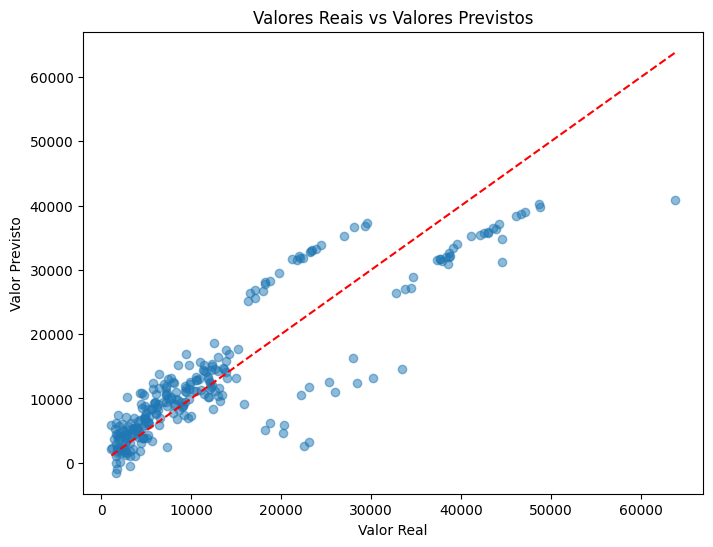

In [194]:
# Comparar valor real vs previsto
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lin, alpha=0.5)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Valores Reais vs Valores Previstos')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

A seguir iremos testar o modelo de regressão polinomial.

In [195]:
# Instanciar e treinar o modelo
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train_prepared, y_train)

# Previsões
y_pred_poly = model_poly.predict(X_test_prepared)

In [196]:
# Métricas para avaliar a performance do modelo
mse_poly = mean_squared_error(y_test, y_pred_poly) # Erro Quadrático Médio
rmse_poly = np.sqrt(mse_poly) # Raiz Do Erro Quadrático Médio
r2_poly = r2_score(y_test, y_pred_poly) # Coeficiente de Determinação
mape_poly = calculate_mape(y_test, y_pred_poly) # Erro Absoluto Percentual Médio

print(f"MSE: {mse_poly:.2f}")
print(f"RMSE: {rmse_poly:.2f}")
print(f"R²: {r2_poly:.2f}")
print(f"MAPE: {mape_poly:.2f}")

MSE: 20712805.99
RMSE: 4551.13
R²: 0.87
MAPE: 30.20


O modelo de regressão polinomial apresentou um score(R²) bem melhor e seus valores de mape e rmse estão bem mais baixos quando comparados com o primeiro modelo testado.

Isso se deve ao fato de que algoritmos de regressão polinomial possuem maior flexibilidade quanto a curva de sua reta (esta não precisa ser reta como no caso da regressão linear) podendo atuar em datasets com variáveis de baixa correlação o que se encaixa com o perfil dos nossos dados.

A imagem abaixo mostra um exemplo da diferença entre regressão linear e polinomial.

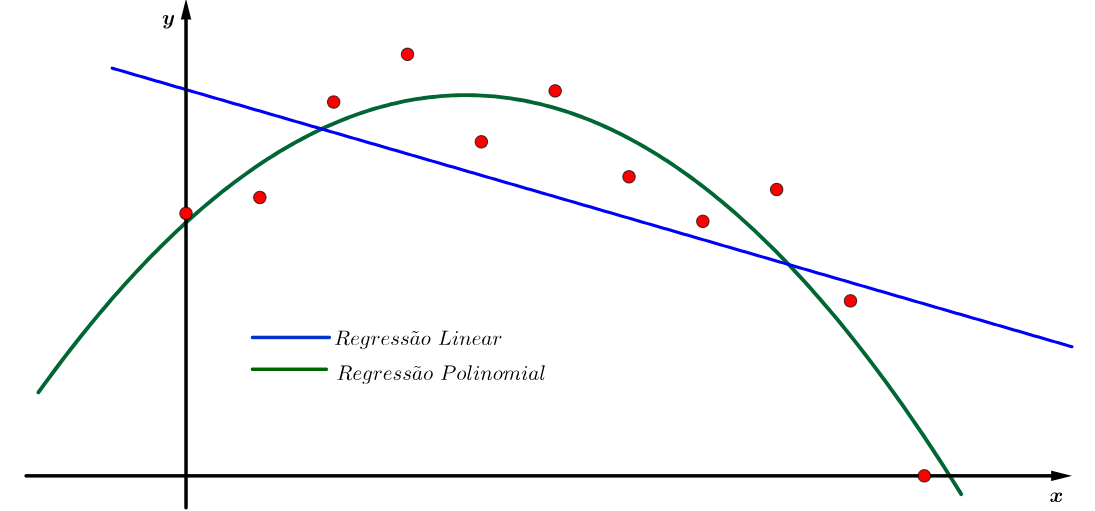

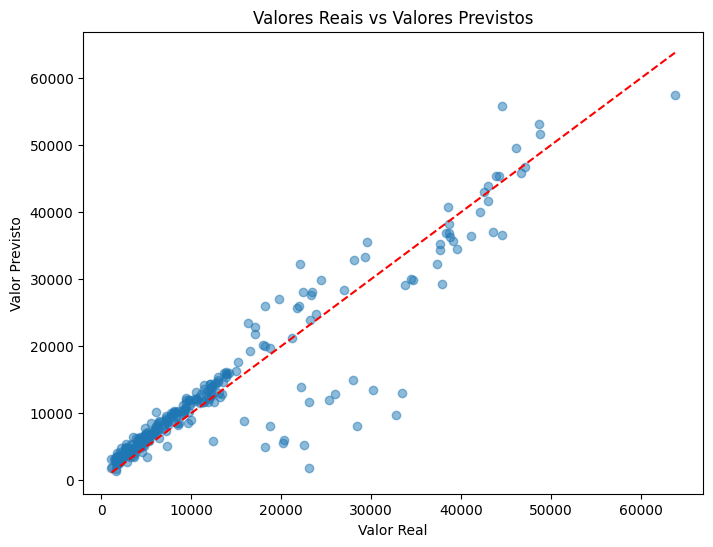

In [197]:
# Comparar valor real vs previsto
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Valores Reais vs Valores Previstos')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

Vamos tambem testar o modelo de árvore de regressão.

In [198]:
# Instanciar e treinar o modelo
model_tree = DecisionTreeRegressor(max_depth=5, min_samples_split=10)
model_tree.fit(X_train_prepared, y_train)

# Previsões
y_pred_tree = model_tree.predict(X_test_prepared)

In [199]:
# Métricas para avaliar a performance do modelo
mse_tree = mean_squared_error(y_test, y_pred_tree) # Erro Quadrático Médio
rmse_tree = np.sqrt(mse_tree) # Raiz Do Erro Quadrático Médio
r2_tree = r2_score(y_test, y_pred_tree) # Coeficiente de Determinação
mape_tree = calculate_mape(y_test, y_pred_tree) # Erro Absoluto Percentual Médio

print(f"MSE: {mse_tree:.2f}")
print(f"RMSE: {rmse_tree:.2f}")
print(f"R²: {r2_tree:.2f}")
print(f"MAPE: {mape_tree:.2f}")

MSE: 25857792.06
RMSE: 5085.06
R²: 0.83
MAPE: 34.55


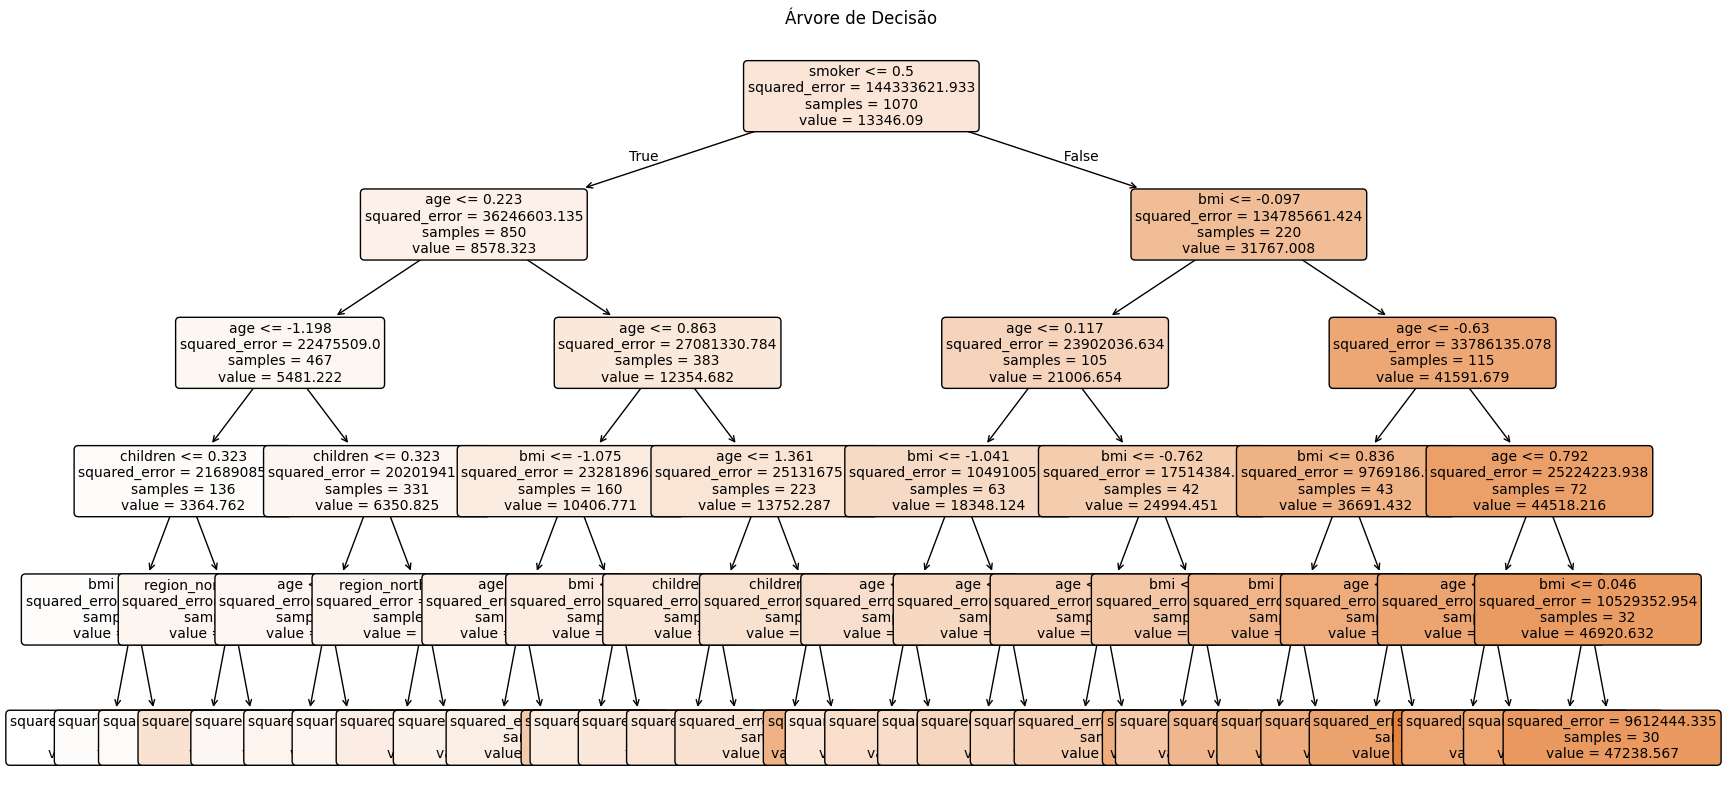

In [200]:
# Visualizar os critérios de divisão adotados pela árvore de regressão
plt.figure(figsize=(20, 10))
plot_tree(model_tree, feature_names=X_train_prepared.columns, filled=True, rounded=True, max_depth=5, fontsize=10)
plt.title("Árvore de Decisão")
plt.show()

O modelo de árvore de regressão obteve um desempenho superior ao de regressão linear mas inferior ao de regressão polinomial.

Observando os critérios de divisão adotados pela árvore de regressão confirmamos a nossa análise anterior que a coluna 'smoker' é a que melhor divide os dados seguida das colunas 'age' e 'bmi'. As outras colunas como 'sex', 'children' ou 'region' possuem pouca relevância na hora de dividir os dados.

Por último vamos testar o modelo de floresta aleatória de regressão.

In [201]:
# Instanciar e treinar o modelo
model_random = RandomForestRegressor(criterion='squared_error', n_estimators=100, max_depth=5, random_state=42)
model_random.fit(X_train_prepared, y_train)

# Previsões
y_pred_random = model_random.predict(X_test_prepared)

In [202]:
# Métricas para avaliar a performance do modelo
mse_random = mean_squared_error(y_test, y_pred_random) # Erro Quadrático Médio
rmse_random = np.sqrt(mse_random) # Raiz Do Erro Quadrático Médio
r2_random = r2_score(y_test, y_pred_random) # Coeficiente de Determinação
mape_random = calculate_mape(y_test, y_pred_random) # Erro Absoluto Percentual Médio

print(f"MSE: {mse_random:.2f}")
print(f"RMSE: {rmse_random:.2f}")
print(f"R²: {r2_random:.2f}")
print(f"MAPE: {mape_random:.2f}")

MSE: 19703452.80
RMSE: 4438.86
R²: 0.87
MAPE: 31.38


O modelo de floresta aleatória de regressão apresentou o mesmo score(R²) que o modelo de regressão polinomial e os valores de mape e rmse
de ambos os modelos estão bem próximos porém vale lembrar que o modelo random florest consome mais recursos computacionais que o modelo polinomial uma vez que o modelo random florest cria várias árvores de regressão.

Vamos visualizar o SHAP de cada um dos nossos modelos testados.


Shap do modelo de Regressão Linear Simples:


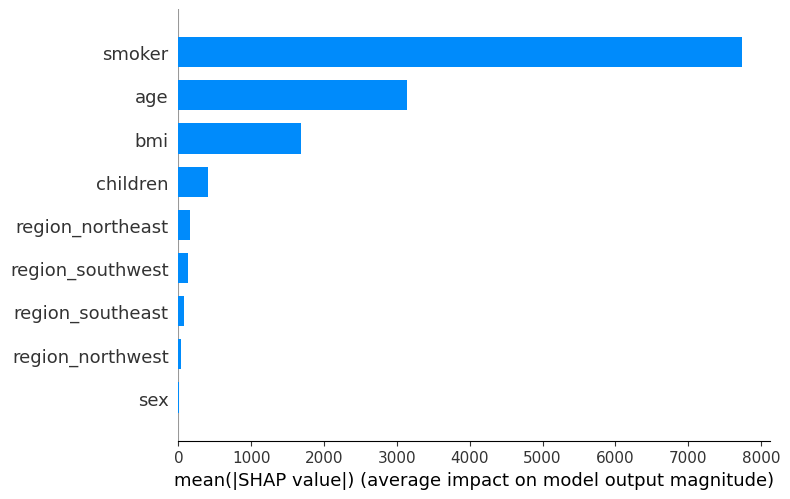


Shap do modelo de Regressão Polinomial:


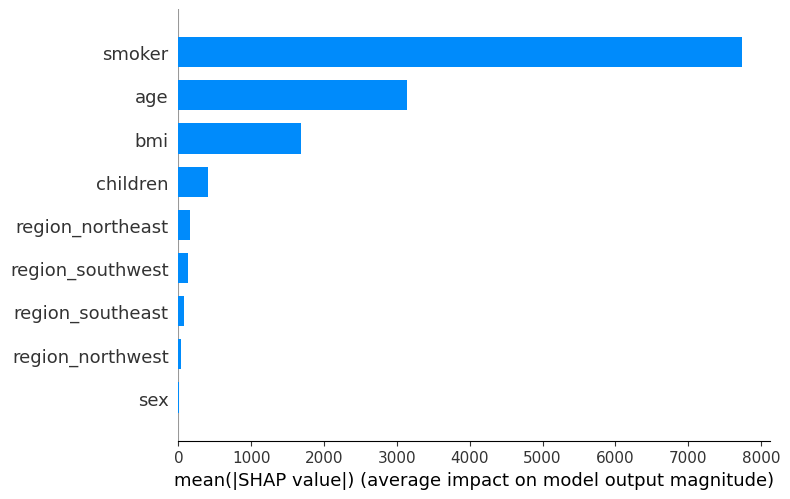


Shap do modelo de Árvore de Regressão:


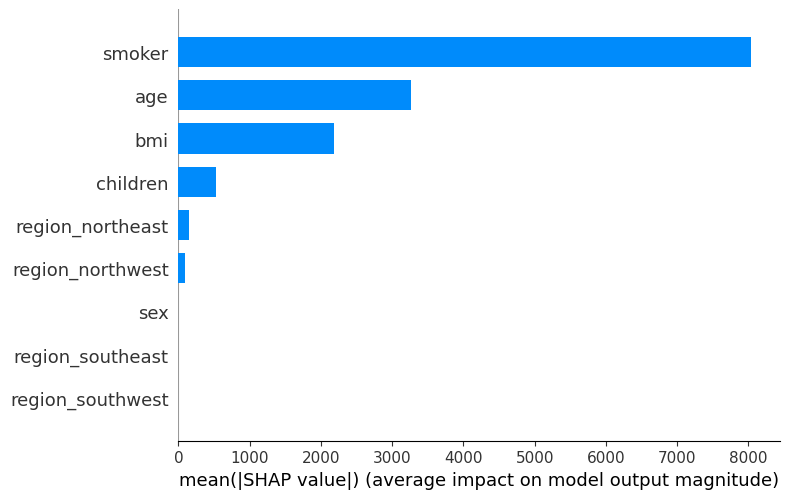


Shap do modelo de Floresta Aleatória de Regressão:


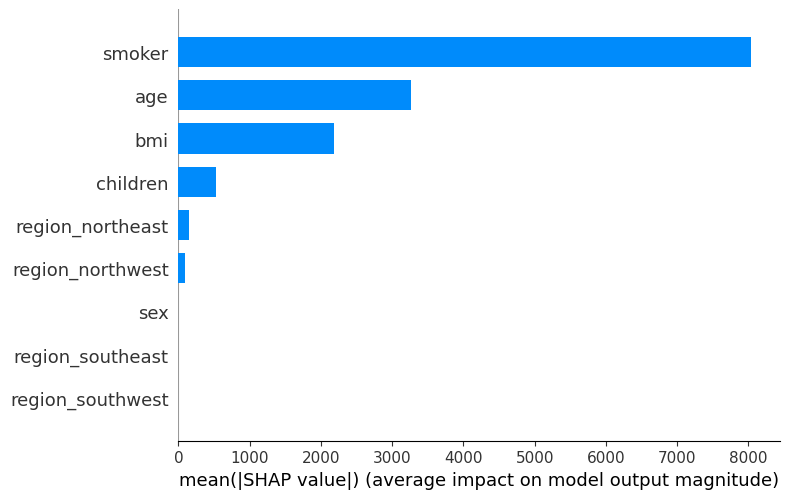

In [203]:
X_test_shap = pd.DataFrame(X_test_prepared, columns=X_test_prepared.columns)

# Criar o shap do modelo de Regressão Linear Simples
explainer_lin = shap.Explainer(model_lin.predict, X_test_shap)
shap_values_lin = explainer_lin(X_test_shap)

# Visualizar os valores do shap de Regressão Linear Simples
print("\nShap do modelo de Regressão Linear Simples:")
shap.summary_plot(shap_values_lin, X_test_shap, plot_type="bar")

# Criar o shap do modelo de Regressão Polinomial
explainer_poly = shap.Explainer(model_lin.predict, X_test_shap)
shap_values_poly = explainer_poly(X_test_shap)

# Visualizar os valores do shap de Regressão Polinomial
print("\nShap do modelo de Regressão Polinomial:")
shap.summary_plot(shap_values_poly, X_test_shap, plot_type="bar")

# Criar o shap do modelo de Árvore de Regressão
explainer_tree = shap.Explainer(model_tree.predict, X_test_shap)
shap_values_tree = explainer_tree(X_test_shap)

# Visualizar os valores do shap de Árvore de Regressão
print("\nShap do modelo de Árvore de Regressão:")
shap.summary_plot(shap_values_tree, X_test_shap, plot_type="bar")

# Criar o shap do modelo de Floresta Aleatória de Regressão
explainer_random = shap.Explainer(model_random.predict, X_test_shap)
shap_values_random = explainer_tree(X_test_shap)

# Visualizar os valores do shap de Floresta Aleatória de Regressão
print("\nShap do modelo de Floresta Aleatória de Regressão:")
shap.summary_plot(shap_values_random, X_test_shap, plot_type="bar")

# ✅ Conclusão

Todos os modelos mostraram limitações devido ao baixo número de features que possuem forte correlação com a target, no entanto, dentre os 4 modelos testados os modelos de regressão polinomial e random florest foram os que apresentaram melhor performance, explicando cerca de 87% da variância dos dados.

Para esse cenário é recomendável utilizar o modelo de regressão polinomial, pois consome menos recursos computacionais do que o modelo de random florest além de ser mais simples de interpretar.

## Sugestões de melhorias

- Adicionar features (de alta correlação) que ajudem a descrever o estado de saúde da pessoa como por exemplo se ela possue problemas de saúde como aids, diabetes, câncer, hipertensão ou que podem contribuir para que isso ocorra como predisposição a alguma(s) doença(s), se a pessoa possue problema de alcoolismo, o nível do colesterol.

- Balancear melhor os dados, vimos que a coluna 'smoker' é a feature com maior correlação com a nossa target porém seus dados estão muito desbalanceados e isso pode impactar no aprendizado dos modelos supervisionados.